Utilização de Filtro FIR e IIR para decomposição de sinal de audio. Atividade da disciplina de Processamento Digital de Sinais - $18/04/2025$.

#by Luiz Henrique S. do Nascimento

In [90]:
import numpy as np  
from scipy.io import wavfile  # para leitura de arquivos .wav
from scipy.signal import find_peaks, firwin, filtfilt, spectrogram, butter  # funções para processamento de sinal
import matplotlib.pyplot as plt 
from sympy import *
from utils import symdisp, symplot, round_expr

# $Filtro~FIR$

# 1. Leitura do sinal de áudio

In [91]:
fs, sinal = wavfile.read('sinal_1.wav')  # Carrega o arquivo: fs = taxa de amostragem (Hz), sinal = dados do áudio.
n = len(sinal) # número total de amostras.
tempo = np.arange(n) / fs # variável para plotagem do tempo.


# 2. Análise Espectral Melhorada

In [92]:
n_fft = 2**18 # implementei essa variável(sugestão do DeepSeek kkkkkkkkk) depois de algumas tentativas, pois melhora a resolução e me entregou a resposta correta, anteiormente estava utilizando o valor default para o parâmetro 'n' na função np.fft(a, n=a), logo o resultado estava saindo errado, com apenas uma componente.
fft_sinal = np.fft.fft(sinal, n=n_fft) # cálculo da FFT.
freqs = np.fft.fftfreq(n_fft, 1/fs)[:n_fft//2] # frequências correspondentes, porém dentro do limite de Nyquist.
magnitude = np.abs(fft_sinal[:n_fft//2]) / n # normalizar a magnitude ignorando o espectro de -pi a pi.

# 3. Detecção de Picos com Parâmetros Ajustados

In [93]:
threshold = 0.001 * np.max(magnitude) # determinação do limiar  na detecção dos picos.
peaks, _ = find_peaks(magnitude, height=threshold, distance=100) # distância maior para evitar duplicatas entre os picos detectados.
num_componentes = len(peaks) # numero de componentes.
freq_componentes = freqs[peaks] # frequência de cada componente.

symdisp(f"Número~de~componentes~identificados: {num_componentes}")
freq_formatadas = [f"{f:.2f}" for f in freq_componentes]
symdisp("Frequências~das~componentes (Hz):", freq_formatadas)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# 4. Espectrograma

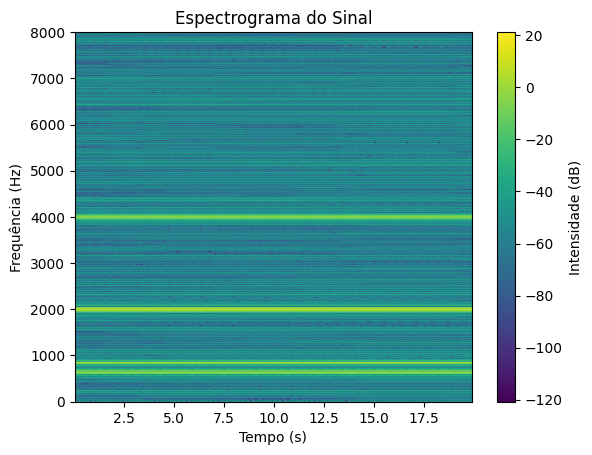

In [94]:
nperseg=2**11 # resolução frequência vs tempo
noverlap=nperseg//2 # suavização temporal
f, t, Sxx = spectrogram(sinal, fs=fs, nperseg=nperseg, noverlap=noverlap)
plt.figure()
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='auto')
plt.colorbar(label='Intensidade (dB)')
plt.ylabel('Frequência (Hz)')
plt.xlabel('Tempo (s)')
plt.title('Espectrograma do Sinal')
plt.show()

# 5. Filtros FIR

In [95]:

if num_componentes > 0:
    ordem_filtro = 501 # outra descoberta(não me lembro de ter visto isso em sala de aula): filtros FIR de ORDEM ÍMPAR garatem simetria nos coeficiente, que é de suma importância para garantia de Fase Linear. 
    sinais_filtrados = [] # vetor vazio a ser preenchido com os sinais filtrados
    for freq in freq_componentes:
        largura_banda = 20 # largura de banda(Hz) bem estreita para evitar sobreposição
        taps = firwin(ordem_filtro, [freq - largura_banda/2, freq + largura_banda/2], fs=fs, pass_zero=False) # filtro FIR, janelamento de Hamming, que retorna os coeficientes do filtro(vetor de tamanaho 501).
        sinal_filtrado = filtfilt(taps, 1.0, sinal) # filtragem sem distorção de fase.
        sinais_filtrados.append(sinal_filtrado) # armazena cada sinal filtrado.

# 6. Plotagem com FFT e das componentes

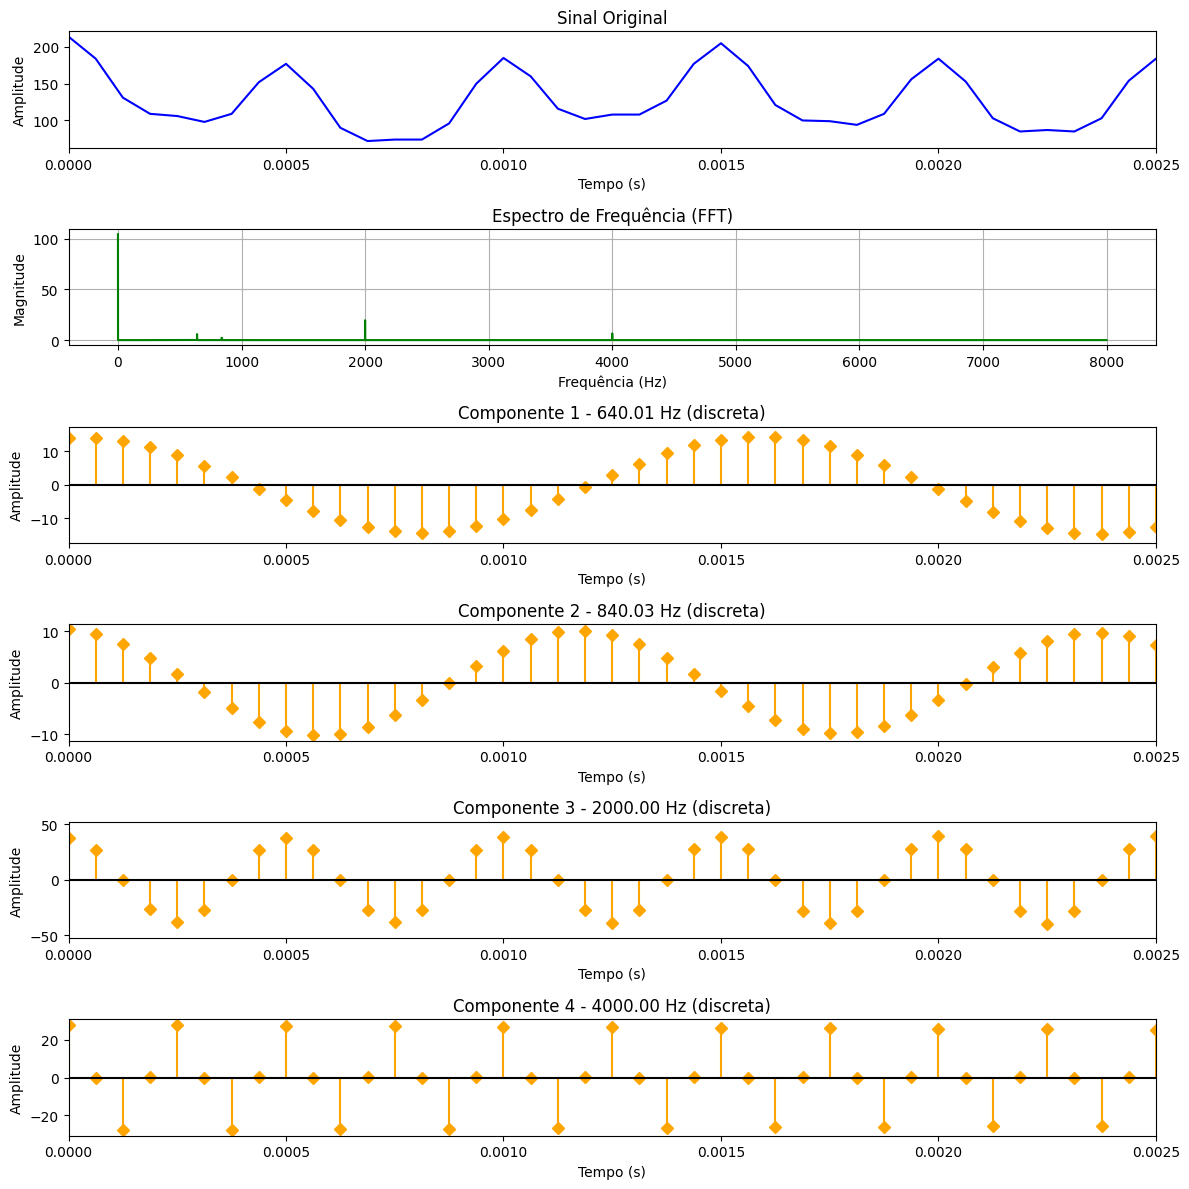

In [96]:

    limite_tempo = 2  # segundos
    plt.figure(figsize=(12, 2 * (num_componentes + 2)))

    # (a) Sinal original
    plt.subplot(num_componentes + 2, 1, 1)
    plt.plot(tempo, sinal, color='blue')
    plt.title("Sinal Original")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, 0.0025)

    # (b) FFT
    plt.subplot(num_componentes + 2, 1, 2)
    plt.plot(freqs, magnitude, color='green')
    plt.title("Espectro de Frequência (FFT)")
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()

    # (c) Componentes com stem()
    for i, (freq, sinal_filtrado) in enumerate(zip(freq_componentes, sinais_filtrados)):
        plt.subplot(num_componentes + 2, 1, i + 3)
        indices_visiveis = tempo <= limite_tempo
        plt.stem(tempo[indices_visiveis], sinal_filtrado[indices_visiveis], linefmt='orange', markerfmt='D', basefmt='k')
        plt.title(f"Componente {i+1} - {freq:.2f} Hz (discreta)")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Amplitude")
        plt.xlim(0, 0.0025)

    plt.tight_layout()
    plt.show()

# Curiosidade

# Resultado das últimas componentes, no plot de forma contínua aparentemente está errado, pois não faz sentido na decomposição haver onda triangular, mas isso acontece devido a interpolação. 

# Contudo não tive exito em resolver esse problema, tentei aumentar a ordem do filtro e mudar o tipo de janelamento, mas o "erro" persistiu.

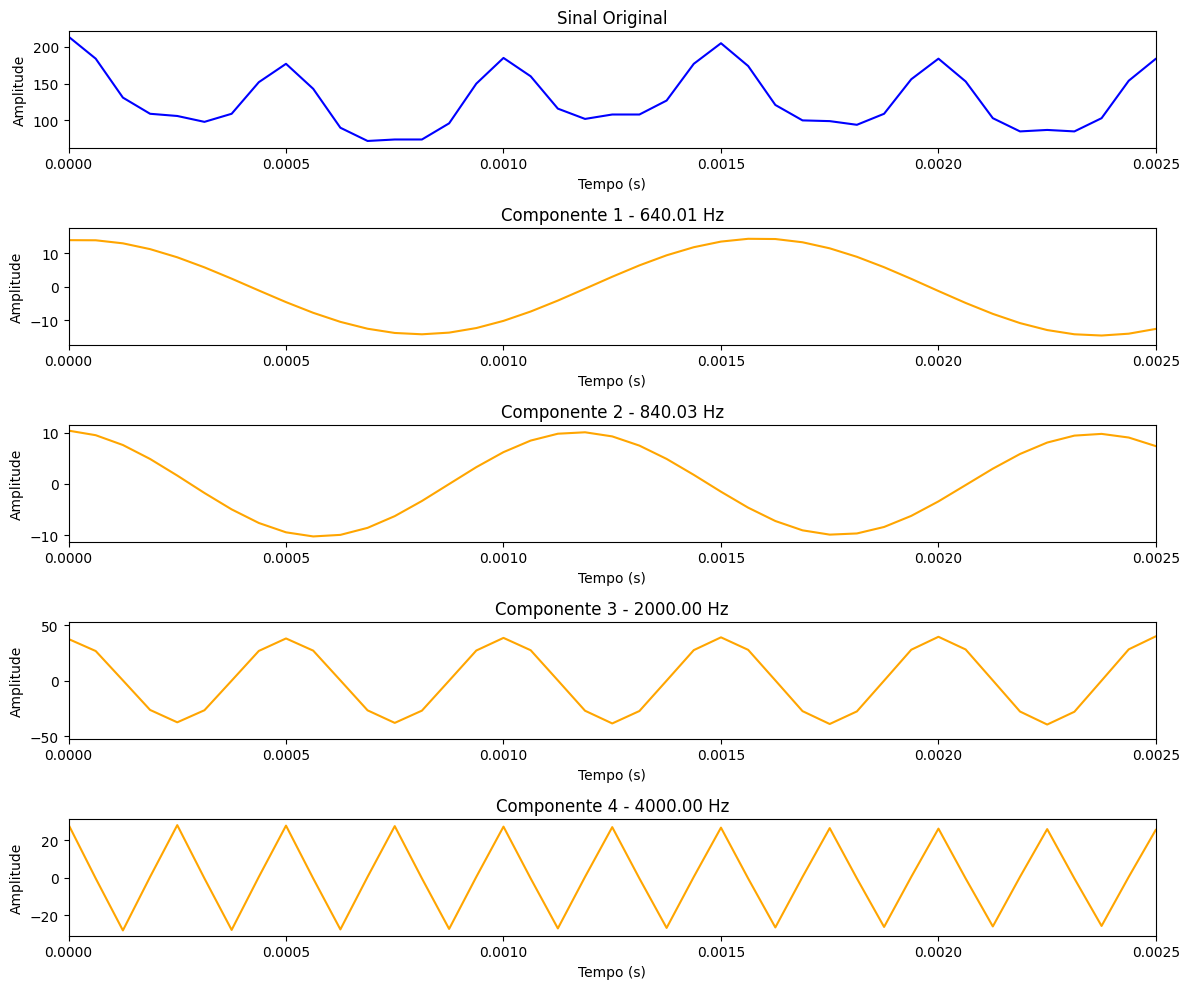

In [97]:
    # Plot dos resultados
    plt.figure(figsize=(12, 2 * (num_componentes + 1)))
    plt.subplot(num_componentes + 1, 1, 1)
    plt.plot(tempo, sinal, color='blue')
    plt.title("Sinal Original")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, 0.0025)

    for i, (freq, sinal_filtrado) in enumerate(zip(freq_componentes, sinais_filtrados)):
        plt.subplot(num_componentes + 1, 1, i + 2)
        plt.plot(tempo, sinal_filtrado, color='orange')
        plt.title(f"Componente {i+1} - {freq:.2f} Hz")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Amplitude")
        plt.xlim(0, 0.0025)
    plt.tight_layout()
    plt.show()

# $Filtro~IIR$

# 1. Projeto de Filtros IIR - Butterworth

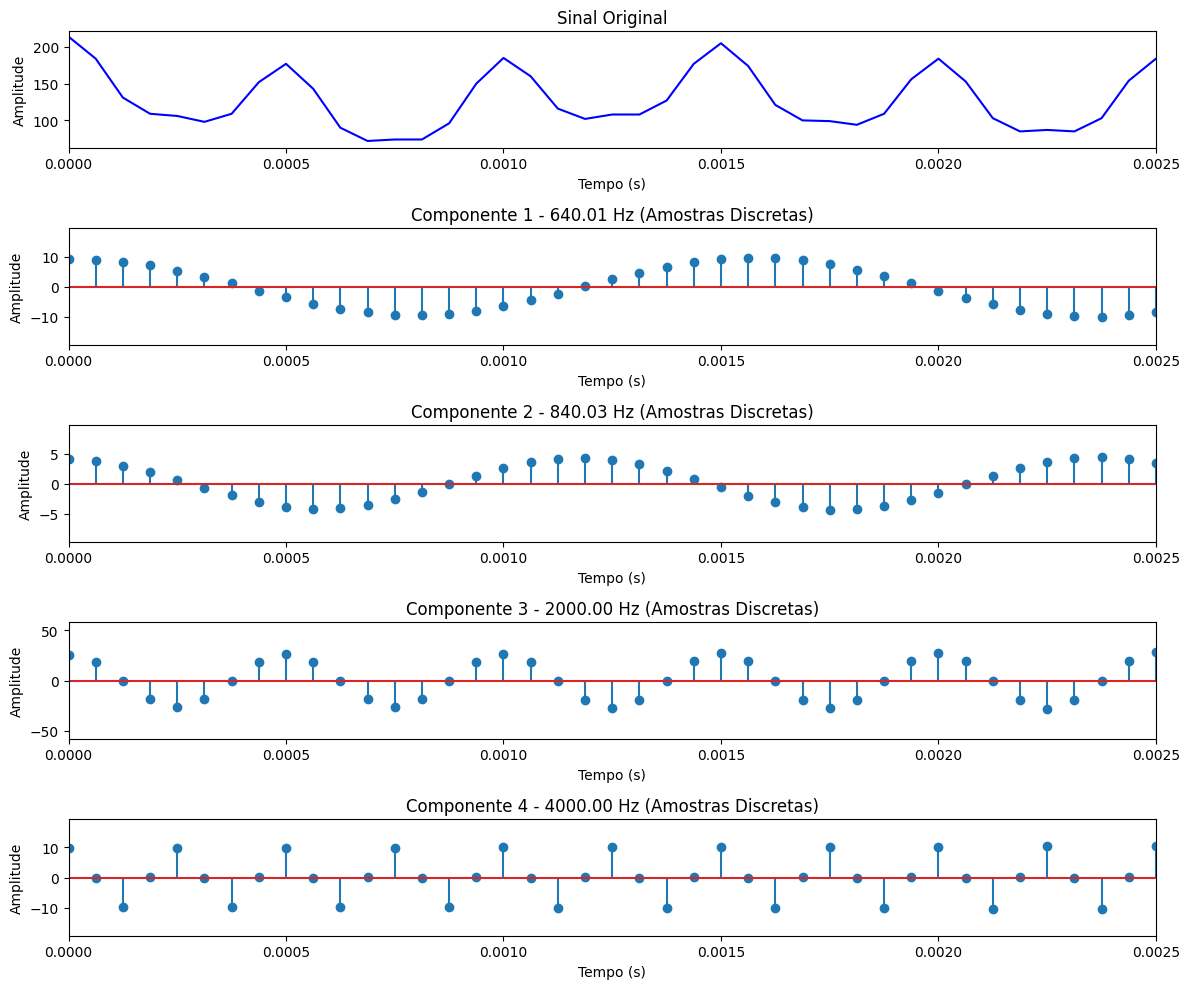

In [98]:
if num_componentes > 0:
    sinais_filtrados = []
    plt.figure(figsize=(12, 2 * (num_componentes + 1)))
    
    # plot dosinal original
    plt.subplot(num_componentes + 1, 1, 1)
    plt.plot(tempo, sinal, color='blue')
    plt.title("Sinal Original")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, 0.0025)

    for i, freq in enumerate(freq_componentes):
        # projeto filtro IIR passa-banda
        largura_banda = 20  # largura da banda passante (Hz)
        ordem_filtro = 4
        low = freq - largura_banda/2
        high = freq + largura_banda/2
        b, a = butter(ordem_filtro, [low, high], btype='bandpass', fs=fs)
        sinal_filtrado = filtfilt(b, a, sinal) # filtragem sem distorção de fase.
        sinais_filtrados.append(sinal_filtrado)

        # nesse passo pode-se subamostrar pra melhorrar a visualização no gráfico, mas deixei sem subamostragem mesmo.
        passo = 1  # mostrar 1 a cada 1 amostra
        tempo_sub = tempo[::passo]
        sinal_sub = sinal_filtrado[::passo]

        # plot das componentes
        plt.subplot(num_componentes + 1, 1, i + 2)
        plt.stem(tempo_sub, sinal_sub)
        plt.title(f"Componente {i+1} - {freq:.2f} Hz (Amostras Discretas)")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Amplitude")
        plt.xlim(0, 0.0025)

    plt.tight_layout()
    plt.show()

# Obs.:

Não entendi por qual motivo o filtro IIR atenuou as componentes, com relação ao FIR. 